**Concept check**

**When would you use a bar chart vs a histogram?**

Bar chart is used for categorical data.
whereas histogram is used for numerical data.

**What is the difference between plt.plot() and sns.lineplot()?**

plt.plot(): is the Matplotlib basic plotting function.

sns.lineplot(): is a seaboarn higher level function work with largest and complex data.

**What does a boxplot actually show — what are the whiskers?**

A boxplot shows how the data is spread and helps us find outliers.
A line in the box show the median.

Whiskers: Show the normal/typical range of the data outside the box.

**How do you plot multiple charts in one figure using Matplotlib?**

use **subplot() **to display multiple charts in one figure.

**What is a heatmap useful for and what kind of data does it work best with?**

A heatmap uses different colors to show values. It is especially useful for seeing relationships between numerical variables.
it work with Numerical data and correlation metrices.

**Implementation Task**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Amazon.csv')
df

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,ORD0099996,2023-03-07,CUST001356,Karan Joshi,P00047,Memory Card 128GB,Electronics,Apex,2,492.34,0.00,78.77,2.75,1066.20,UPI,Delivered,Jacksonville,FL,India,SELL00041
99996,ORD0099997,2021-11-24,CUST031254,Sunita Kapoor,P00046,Car Charger,Sports & Outdoors,Apex,5,449.30,0.00,179.72,6.07,2432.29,Credit Card,Delivered,San Jose,CA,United States,SELL01449
99997,ORD0099998,2023-04-29,CUST012579,Aman Gupta,P00030,Dress Shirt,Sports & Outdoors,BrightLux,4,232.40,0.00,74.37,12.43,1016.40,Cash on Delivery,Delivered,Indianapolis,IN,United States,SELL00028
99998,ORD0099999,2021-11-01,CUST026243,Simran Gupta,P00046,Car Charger,Sports & Outdoors,HomeEase,1,294.05,0.00,23.52,13.09,330.66,Debit Card,Delivered,Charlotte,NC,United States,SELL00324


In [5]:
df.shape

(100000, 20)

In [6]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


**HISTOGRAM**

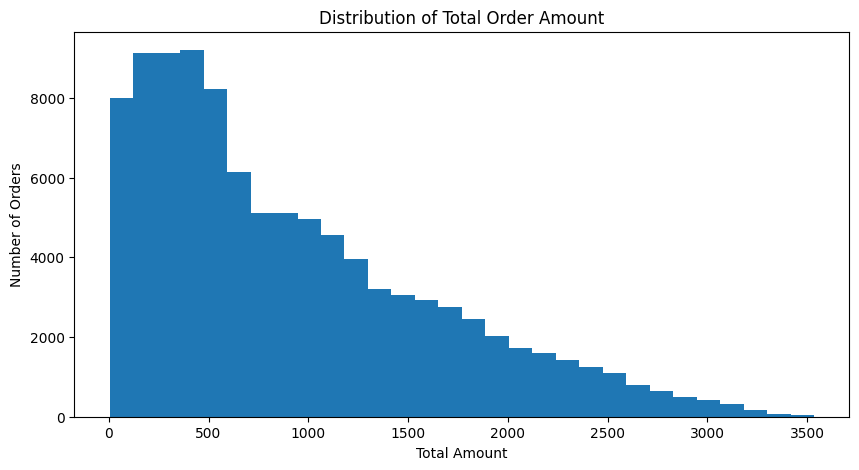

In [7]:
plt.figure(figsize=(10,5))
plt.hist(df['TotalAmount'].dropna(), bins=30)
plt.title('Distribution of Total Order Amount')
plt.xlabel('Total Amount')
plt.ylabel('Number of Orders')
plt.show()

Histogram tell us how order amount is distributed.it help us to check on which price order falls mostly.

**BAR CHART**

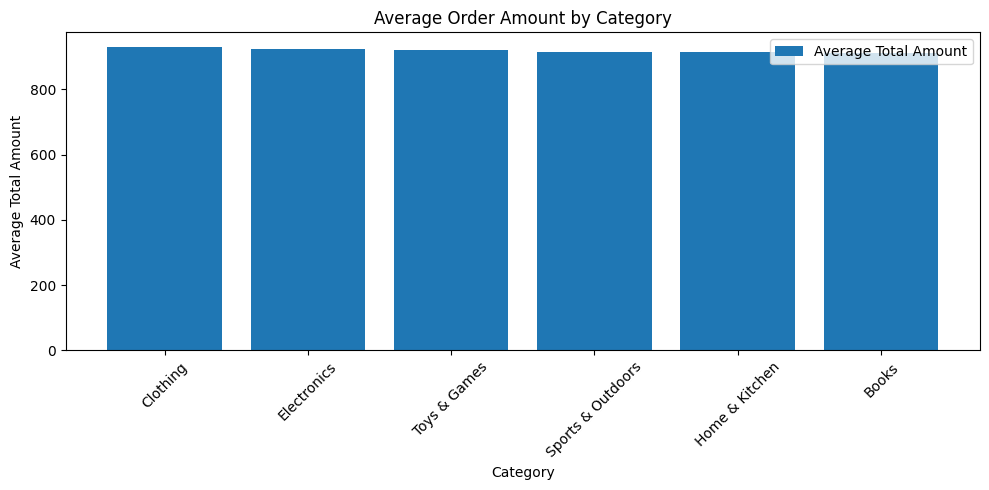

In [8]:
avg_category = df.groupby('Category')['TotalAmount'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(avg_category.index, avg_category.values)
plt.title('Average Order Amount by Category')
plt.xlabel('Category')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=45)
plt.legend(['Average Total Amount'])
plt.tight_layout()
plt.show()


**Boxplot — Distribution and Outliers of Total Amount**

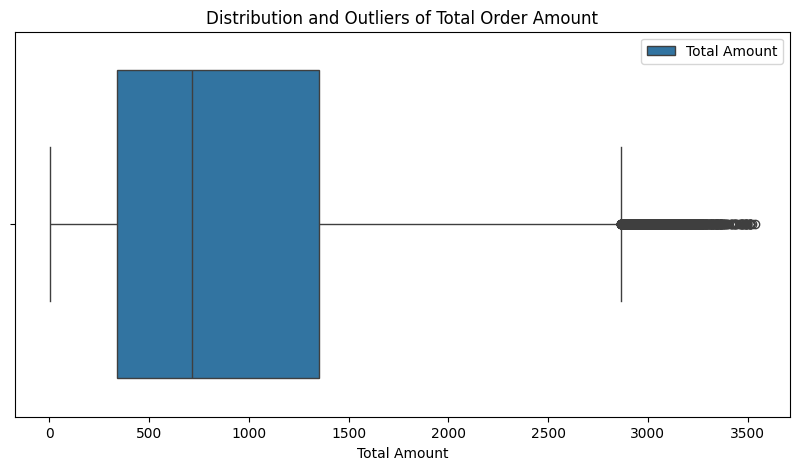

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['TotalAmount'].dropna())
plt.title('Distribution and Outliers of Total Order Amount')
plt.xlabel('Total Amount')
plt.legend(['Total Amount'])
plt.show()


**CORRELATION HEATMAP**

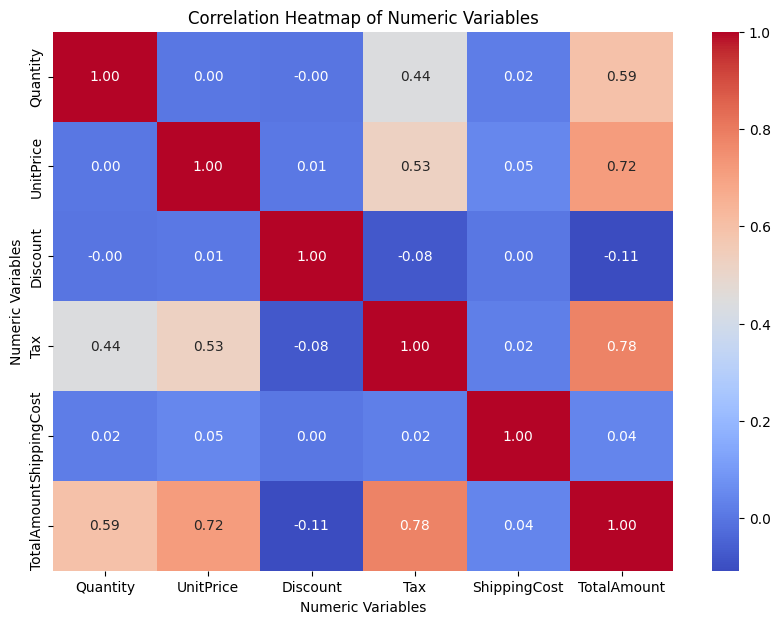

In [10]:
numeric_columns = df.select_dtypes(include='number')
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(10,7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.xlabel('Numeric Variables')
plt.ylabel('Numeric Variables')
plt.show()

**Bar Chart — Number of Orders by Order Status**

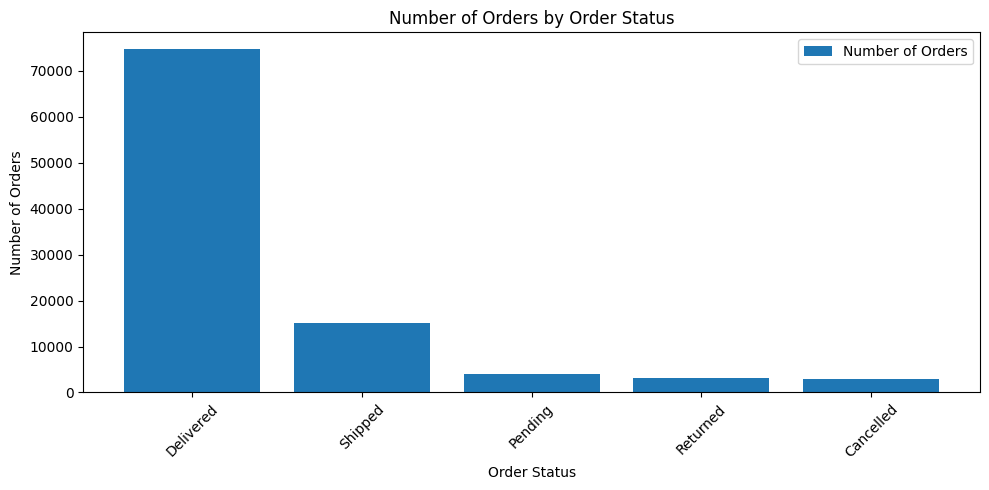

In [11]:
status_counts = df['OrderStatus'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(status_counts.index, status_counts.values)
plt.title('Number of Orders by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend(['Number of Orders'])
plt.tight_layout()
plt.show()

Total Implementation

1. The histogram shows the distribution of order amounts.
2. The category bar chart compares average order values.
3. The boxplot shows spread and possible outliers.
4. The heatmap shows relationships between numeric variables.
5. The order-status chart shows the number of orders in each status.
